#  TRABAJO FINAL - MACHINE LEARNING
## Caso de Estudio: Titanic — Predicción de Supervivencia

## Elaborado por:

### Santiago Restrepo Arcila
### Diego Alejandro Naranjo Arcila
### Jhoan Stiward Cordoba Quejada
### Jose Manuel Herrera Giraldo

---

> **Dataset:** `seaborn.load_dataset('titanic')`  
> **Tipo de problema:** Aprendizaje Supervisado — Clasificación Binaria  
> **Variable objetivo:** `survived` (0 = No sobrevivió, 1 = Sobrevivió)

---

## 📋 Estructura del Notebook (CRISP-DM)

| Fase | Contenido |
|------|-----------|
| 1. Business Understanding | Definición del problema, justificación y criterios de éxito |
| 2. Data Understanding | Carga, descripción, estadísticas, visualización |
| 3. Data Preparation | Imputación, limpieza, encoding, normalización, split |
| 4. Modeling | Regresión Logística, Árbol de Decisión, KNN |
| 5. Evaluation | Métricas, comparación de modelos, análisis ético |
| 6. Deployment | Conclusiones, limitaciones, pasos a producción |

---
# FASE 1: BUSINESS UNDERSTANDING
---

## 1.1 Definición del Problema

El hundimiento del RMS Titanic en abril de 1912 es uno de los naufragios más conocidos de la historia. De las 2.224 personas a bordo, más de 1.500 murieron. Si bien hubo un componente de suerte, ciertos grupos de personas tenían más probabilidades de sobrevivir que otros.

**¿Qué se busca predecir?**  
La **supervivencia de un pasajero** (`survived = 1`) o su fallecimiento (`survived = 0`), a partir de características como edad, género, clase de pasaje, tarifa y puerto de embarque.

## 1.2 Justificación

Este problema tiene relevancia en varios frentes:
- **Histórico/social:** Revela patrones de inequidad (clase social, género, edad) en situaciones de emergencia.
- **Metodológico:** Es un caso de clasificación binaria limpio y representativo, ideal para comparar modelos.
- **Ético:** Permite reflexionar sobre sesgos de datos relacionados con género e ingresos, algo clave en ML responsable.

## 1.3 Criterios de Éxito

Dado que estamos ante un problema de **clasificación binaria** donde la detección correcta de supervivientes es importante (pero también lo es no clasificar erróneamente a fallecidos como supervivientes), se usarán las siguientes métricas:

| Métrica principal | Justificación |
|-------------------|---------------|
| **F1-Score** | Balance entre Precision y Recall; adecuado ante ligero desbalance de clases |
| **Accuracy** | Proporción global de predicciones correctas |
| **Recall** | Relevante si queremos minimizar falsos negativos (pasajeros que sobrevivieron pero el modelo dijo que no) |
| **Precision** | Calidad de los positivos predichos |

**Meta mínima:** Accuracy ≥ 0.78 y F1-Score ≥ 0.75 en el conjunto de prueba.

In [50]:
# FASE 1 - INSTALACIONES Y LIBRERÍAS

# Instalamos librerías

import subprocess, sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Preprocesamiento y modelado
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier

# Métricas de evaluación
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc,
    ConfusionMatrixDisplay
)

# Estadísticas
from scipy.stats import ks_2samp
import joblib

# Configuración global de gráficos
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12
sns.set_theme(style='whitegrid', palette='Set2')

print(' Librerías cargadas correctamente')
print(f'   pandas {pd.__version__} | numpy {np.__version__}')

 Librerías cargadas correctamente
   pandas 3.0.3 | numpy 2.4.6


---
# FASE 2: DATA UNDERSTANDING
---

## 2.1 Carga del Dataset

Cargamos el dataset oficial de Titanic desde la función de Seaborn, tal como lo especifica el documento del curso.

In [51]:
# FASE 2.1 - CARGA DEL DATASET


# Cargamos el dataset
df_raw = sns.load_dataset('titanic')

print('=' * 55)
print('       DATASET: TITANIC — CARGA EXITOSA')
print('=' * 55)
print(f'  Filas     : {df_raw.shape[0]}')
print(f'  Columnas  : {df_raw.shape[1]}')
print(f'  Memoria   : {df_raw.memory_usage(deep=True).sum() / 1024:.1f} KB')
print('=' * 55)

# Primeras filas
print('\n Primeras 10 filas del dataset:')
df_raw.head(10)

       DATASET: TITANIC — CARGA EXITOSA
  Filas     : 891
  Columnas  : 15
  Memoria   : 100.4 KB

 Primeras 10 filas del dataset:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False
8,1,3,female,27.0,0,2,11.1333,S,Third,woman,False,NaN,Southampton,yes,False
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False


## 2.2 Descripción de Variables

Antes de hacer cualquier análisis, es fundamental entender qué representa cada columna.

| Variable | Tipo | Descripción |
|----------|------|-------------|
| `survived` | int (objetivo) | 0 = No sobrevivió, 1 = Sobrevivió |
| `pclass` | int ordinal | Clase del pasaje (1 = 1ra, 2 = 2da, 3 = 3ra) |
| `sex` | object | Género del pasajero |
| `age` | float | Edad en años |
| `sibsp` | int | Número de hermanos/cónyuge a bordo |
| `parch` | int | Número de padres/hijos a bordo |
| `fare` | float | Tarifa pagada por el pasaje |
| `embarked` | object | Puerto de embarque (C=Cherburgo, Q=Queenstown, S=Southampton) |
| `class` | object | Clase (duplicada de pclass, en texto) |
| `who` | object | Clasificación: man/woman/child |
| `adult_male` | bool | ¿Es hombre adulto? |
| `deck` | object | Cubierta del camarote (muy incompleto) |
| `embark_town` | object | Ciudad de embarque (duplicada de embarked) |
| `alive` | object | Duplicada de survived en texto |
| `alone` | bool | ¿Viaja solo? |

In [52]:
# FASE 2.2 - TIPOS DE DATOS Y RESUMEN ESTADÍSTICO


print(' INFORMACIÓN GENERAL DEL DATASET:')
print('-' * 45)
df_raw.info()

print('\n RESUMEN ESTADÍSTICO — Variables Numéricas:')
display(df_raw.describe().round(2))

print('\n RESUMEN ESTADÍSTICO — Variables Categóricas:')
display(df_raw.describe(include='object').T)

 INFORMACIÓN GENERAL DEL DATASET:
---------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 100.4 KB

 RESUMEN EST

,survived,pclass,age,sibsp,parch,fare
count,891.00,891.00,714.00,891.00,891.00,891.00
mean,0.38,2.31,29.70,0.52,0.38,32.20
std,0.49,0.84,14.53,1.10,0.81,49.69
min,0.00,1.00,0.42,0.00,0.00,0.00
25%,0.00,2.00,20.12,0.00,0.00,7.91
50%,0.00,3.00,28.00,0.00,0.00,14.45
75%,1.00,3.00,38.00,1.00,0.00,31.00
max,1.00,3.00,80.00,8.00,6.00,512.33



 RESUMEN ESTADÍSTICO — Variables Categóricas:


,count,unique,top,freq
sex,891,2,male,577
embarked,889,3,S,644
who,891,3,man,537
embark_town,889,3,Southampton,644
alive,891,2,no,549


  VARIABLES CON VALORES FALTANTES:


,Valores Faltantes,Porcentaje (%)
deck,688,77.22
age,177,19.87
embarked,2,0.22
embark_town,2,0.22


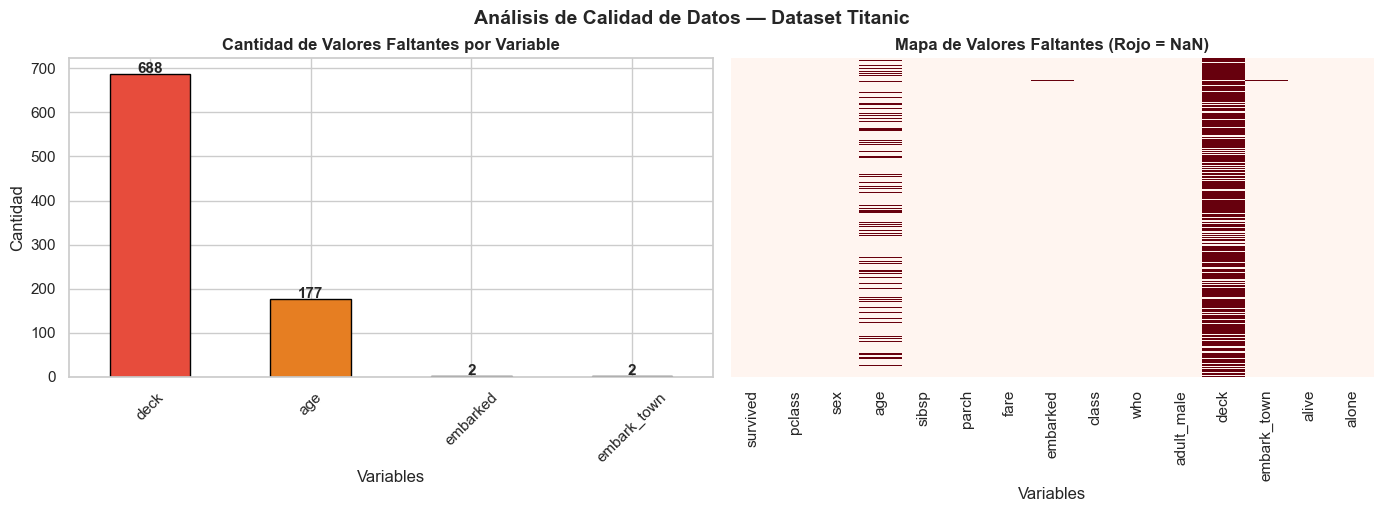


 INTERPRETACIÓN:
  - deck: 77% faltante → se eliminará (demasiado incompleta para imputar)
  - age: 19.9% faltante → se imputará con la mediana por grupo (pclass+sex)
  - embarked: 0.2% faltante → se imputará con la moda


In [53]:
# FASE 2.3 - ANÁLISIS DE VALORES FALTANTES

# Calculamos valores faltantes y porcentaje
faltantes = df_raw.isnull().sum()
porcentaje = (faltantes / len(df_raw) * 100).round(2)

tabla_faltantes = pd.DataFrame({
    'Valores Faltantes': faltantes,
    'Porcentaje (%)': porcentaje
}).sort_values('Valores Faltantes', ascending=False)

tabla_faltantes = tabla_faltantes[tabla_faltantes['Valores Faltantes'] > 0]

print('  VARIABLES CON VALORES FALTANTES:')
display(tabla_faltantes)

# Gráfico de barras
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

tabla_faltantes['Valores Faltantes'].plot(
    kind='bar', ax=axes[0], color=['#e74c3c', '#e67e22', '#3498db'],
    edgecolor='black'
)
axes[0].set_title('Cantidad de Valores Faltantes por Variable', fontweight='bold')
axes[0].set_xlabel('Variables')
axes[0].set_ylabel('Cantidad')
axes[0].tick_params(axis='x', rotation=45)
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 2,
                 f'{bar.get_height():.0f}', ha='center', fontsize=11, fontweight='bold')

# Mapa de calor de nulos
sns.heatmap(df_raw.isnull(), cbar=False, ax=axes[1], cmap='Reds', yticklabels=False)
axes[1].set_title('Mapa de Valores Faltantes (Rojo = NaN)', fontweight='bold')
axes[1].set_xlabel('Variables')

plt.tight_layout()
plt.suptitle('Análisis de Calidad de Datos — Dataset Titanic', y=1.02, fontsize=14, fontweight='bold')
plt.show()

print('\n INTERPRETACIÓN:')
print('  - deck: 77% faltante → se eliminará (demasiado incompleta para imputar)')
print('  - age: 19.9% faltante → se imputará con la mediana por grupo (pclass+sex)')
print('  - embarked: 0.2% faltante → se imputará con la moda')

 DISTRIBUCIÓN DE LA VARIABLE OBJETIVO:
   No sobrevivió (0): 549 pasajeros (61.6%)
   Sobrevivió    (1): 342 pasajeros (38.4%)
   Desbalance moderado: ratio 1.61:1


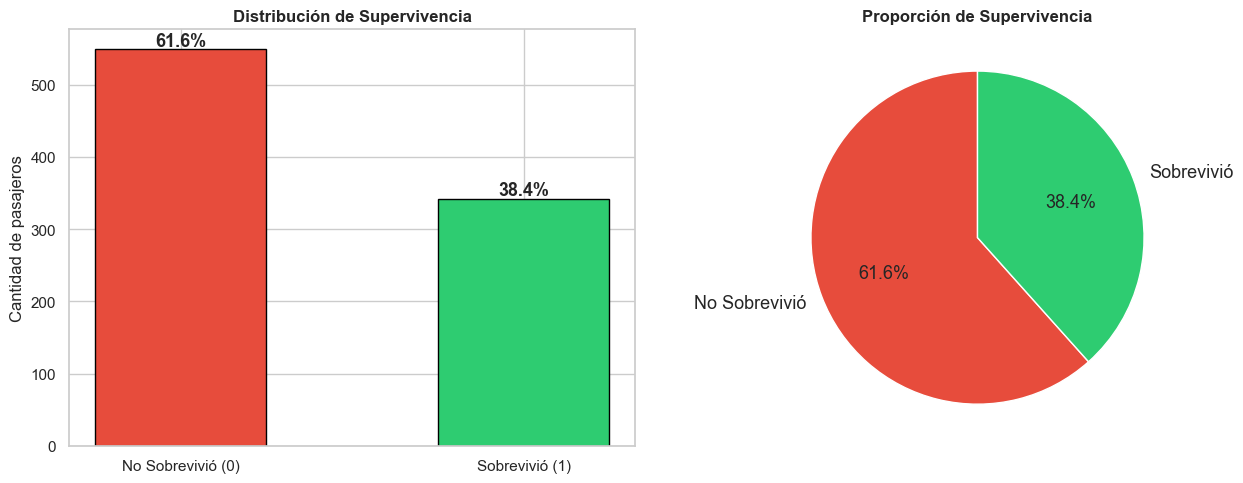


 El dataset presenta un desbalance moderado (61.6% vs 38.4%).
   No es severo, pero se tendrá en cuenta al evaluar con F1-Score.


In [54]:
# FASE 2.4 - ANÁLISIS DE LA VARIABLE OBJETIVO: SURVIVED

conteo = df_raw['survived'].value_counts()
porcentaje_sv = df_raw['survived'].value_counts(normalize=True) * 100

print(' DISTRIBUCIÓN DE LA VARIABLE OBJETIVO:')
print(f'   No sobrevivió (0): {conteo[0]} pasajeros ({porcentaje_sv[0]:.1f}%)')
print(f'   Sobrevivió    (1): {conteo[1]} pasajeros ({porcentaje_sv[1]:.1f}%)')
print(f'   Desbalance moderado: ratio {conteo[0]/conteo[1]:.2f}:1')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Gráfico de barras
bars = axes[0].bar(['No Sobrevivió (0)', 'Sobrevivió (1)'],
                   conteo.values, color=['#e74c3c', '#2ecc71'], edgecolor='black', width=0.5)
axes[0].set_title('Distribución de Supervivencia', fontweight='bold')
axes[0].set_ylabel('Cantidad de pasajeros')
for bar, pct in zip(bars, porcentaje_sv.values):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 5,
                 f'{pct:.1f}%', ha='center', fontsize=13, fontweight='bold')

# Gráfico circular
axes[1].pie(conteo.values, labels=['No Sobrevivió', 'Sobrevivió'],
            colors=['#e74c3c', '#2ecc71'], autopct='%1.1f%%',
            startangle=90, textprops={'fontsize': 13})
axes[1].set_title('Proporción de Supervivencia', fontweight='bold')

plt.tight_layout()
plt.show()

print('\n El dataset presenta un desbalance moderado (61.6% vs 38.4%).')
print('   No es severo, pero se tendrá en cuenta al evaluar con F1-Score.')

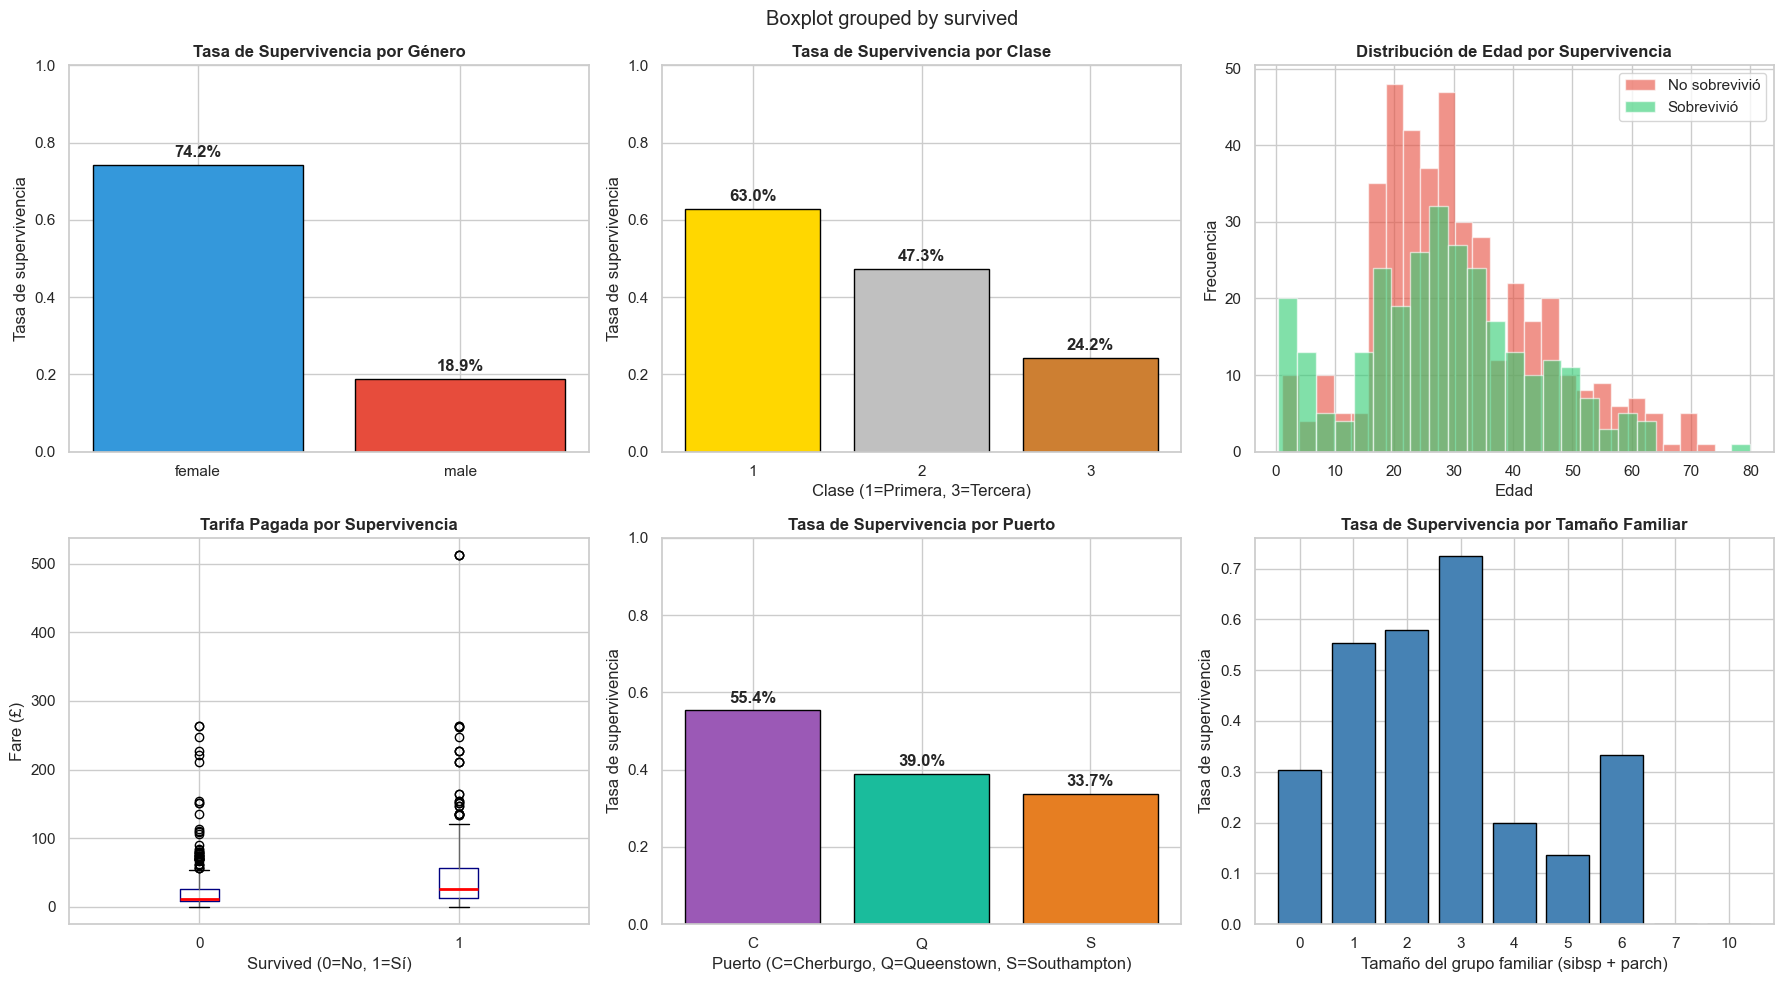


 HALLAZGOS CLAVE DEL DATA UNDERSTANDING:
  ✔ Las MUJERES sobrevivieron mucho más (74%) que los hombres (18%)
  ✔ Los de PRIMERA CLASE tuvieron mayor tasa de supervivencia (63%)
  ✔ Los NIÑOS y personas jóvenes tuvieron ventaja relativa
  ✔ Mayor tarifa pagada se asocia a mayor supervivencia (correlaciona con clase)
  ✔ Viajar solo o con familia pequeña (1-3) da mayor tasa de supervivencia


In [55]:
# FASE 2.5 - VISUALIZACIÓN: RELACIONES CON LA VARIABLE OBJETIVO


fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Relación de Variables con la Supervivencia', fontsize=16, fontweight='bold')

# 1. Supervivencia por Género
sv_sexo = df_raw.groupby('sex')['survived'].mean().reset_index()
axes[0,0].bar(sv_sexo['sex'], sv_sexo['survived'],
              color=['#3498db', '#e74c3c'], edgecolor='black')
axes[0,0].set_title('Tasa de Supervivencia por Género', fontweight='bold')
axes[0,0].set_ylabel('Tasa de supervivencia')
axes[0,0].set_ylim(0, 1)
for i, v in enumerate(sv_sexo['survived']):
    axes[0,0].text(i, v + 0.02, f'{v:.1%}', ha='center', fontweight='bold')

# 2. Supervivencia por Clase
sv_clase = df_raw.groupby('pclass')['survived'].mean().reset_index()
axes[0,1].bar(sv_clase['pclass'].astype(str), sv_clase['survived'],
              color=['gold', 'silver', '#cd7f32'], edgecolor='black')
axes[0,1].set_title('Tasa de Supervivencia por Clase', fontweight='bold')
axes[0,1].set_xlabel('Clase (1=Primera, 3=Tercera)')
axes[0,1].set_ylabel('Tasa de supervivencia')
axes[0,1].set_ylim(0, 1)
for i, v in enumerate(sv_clase['survived']):
    axes[0,1].text(i, v + 0.02, f'{v:.1%}', ha='center', fontweight='bold')

# 3. Distribución de Edad por Supervivencia
df_raw[df_raw['survived']==0]['age'].dropna().hist(
    ax=axes[0,2], alpha=0.6, color='#e74c3c', label='No sobrevivió', bins=25)
df_raw[df_raw['survived']==1]['age'].dropna().hist(
    ax=axes[0,2], alpha=0.6, color='#2ecc71', label='Sobrevivió', bins=25)
axes[0,2].set_title('Distribución de Edad por Supervivencia', fontweight='bold')
axes[0,2].set_xlabel('Edad')
axes[0,2].set_ylabel('Frecuencia')
axes[0,2].legend()

# 4. Tarifa (Fare) por Supervivencia
df_raw.boxplot(column='fare', by='survived', ax=axes[1,0],
               boxprops=dict(color='navy'), medianprops=dict(color='red', linewidth=2))
axes[1,0].set_title('Tarifa Pagada por Supervivencia', fontweight='bold')
axes[1,0].set_xlabel('Survived (0=No, 1=Sí)')
axes[1,0].set_ylabel('Fare (£)')
plt.sca(axes[1,0])
plt.title('Tarifa Pagada por Supervivencia', fontweight='bold')

# 5. Puerto de Embarque por Supervivencia
sv_embarked = df_raw.groupby('embarked')['survived'].mean().reset_index()
axes[1,1].bar(sv_embarked['embarked'], sv_embarked['survived'],
              color=['#9b59b6', '#1abc9c', '#e67e22'], edgecolor='black')
axes[1,1].set_title('Tasa de Supervivencia por Puerto', fontweight='bold')
axes[1,1].set_xlabel('Puerto (C=Cherburgo, Q=Queenstown, S=Southampton)')
axes[1,1].set_ylabel('Tasa de supervivencia')
axes[1,1].set_ylim(0, 1)
for i, v in enumerate(sv_embarked['survived']):
    axes[1,1].text(i, v + 0.02, f'{v:.1%}', ha='center', fontweight='bold')

# 6. Familiares a bordo
df_raw['family_size'] = df_raw['sibsp'] + df_raw['parch']
sv_fam = df_raw.groupby('family_size')['survived'].mean().reset_index()
axes[1,2].bar(sv_fam['family_size'].astype(str), sv_fam['survived'],
              color='steelblue', edgecolor='black')
axes[1,2].set_title('Tasa de Supervivencia por Tamaño Familiar', fontweight='bold')
axes[1,2].set_xlabel('Tamaño del grupo familiar (sibsp + parch)')
axes[1,2].set_ylabel('Tasa de supervivencia')

plt.tight_layout()
plt.show()

print('\n HALLAZGOS CLAVE DEL DATA UNDERSTANDING:')
print('  ✔ Las MUJERES sobrevivieron mucho más (74%) que los hombres (18%)')
print('  ✔ Los de PRIMERA CLASE tuvieron mayor tasa de supervivencia (63%)')
print('  ✔ Los NIÑOS y personas jóvenes tuvieron ventaja relativa')
print('  ✔ Mayor tarifa pagada se asocia a mayor supervivencia (correlaciona con clase)')
print('  ✔ Viajar solo o con familia pequeña (1-3) da mayor tasa de supervivencia')

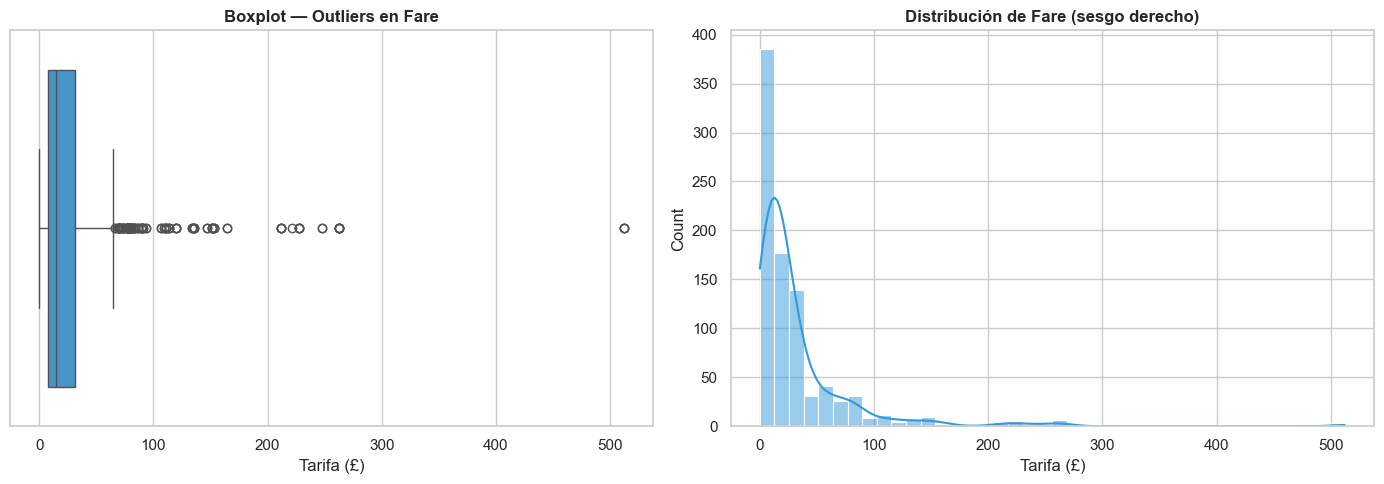

 Estadísticas de Fare:
count    891.00
mean      32.20
std       49.69
min        0.00
25%        7.91
50%       14.45
75%       31.00
max      512.33
Name: fare, dtype: float64

  Outliers detectados (IQR): 116 registros con fare > £65.63
   Decisión: Se conservarán pero se aplicará StandardScaler para reducir su impacto.


In [56]:
# FASE 2.6 - ANÁLISIS DE OUTLIERS EN FARE

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x=df_raw['fare'], ax=axes[0], color='#3498db')
axes[0].set_title('Boxplot — Outliers en Fare', fontweight='bold')
axes[0].set_xlabel('Tarifa (£)')

sns.histplot(df_raw['fare'], bins=40, kde=True, ax=axes[1], color='#3498db')
axes[1].set_title('Distribución de Fare (sesgo derecho)', fontweight='bold')
axes[1].set_xlabel('Tarifa (£)')

plt.tight_layout()
plt.show()

# rango intercuartílico para detectar outliers
Q1 = df_raw['fare'].quantile(0.25)
Q3 = df_raw['fare'].quantile(0.75)
IQR = Q3 - Q1
limite_sup = Q3 + 1.5 * IQR

outliers_fare = df_raw[df_raw['fare'] > limite_sup]

print(f' Estadísticas de Fare:')
print(df_raw['fare'].describe().round(2))
print(f'\n  Outliers detectados (IQR): {len(outliers_fare)} registros con fare > £{limite_sup:.2f}')
print('   Decisión: Se conservarán pero se aplicará StandardScaler para reducir su impacto.')

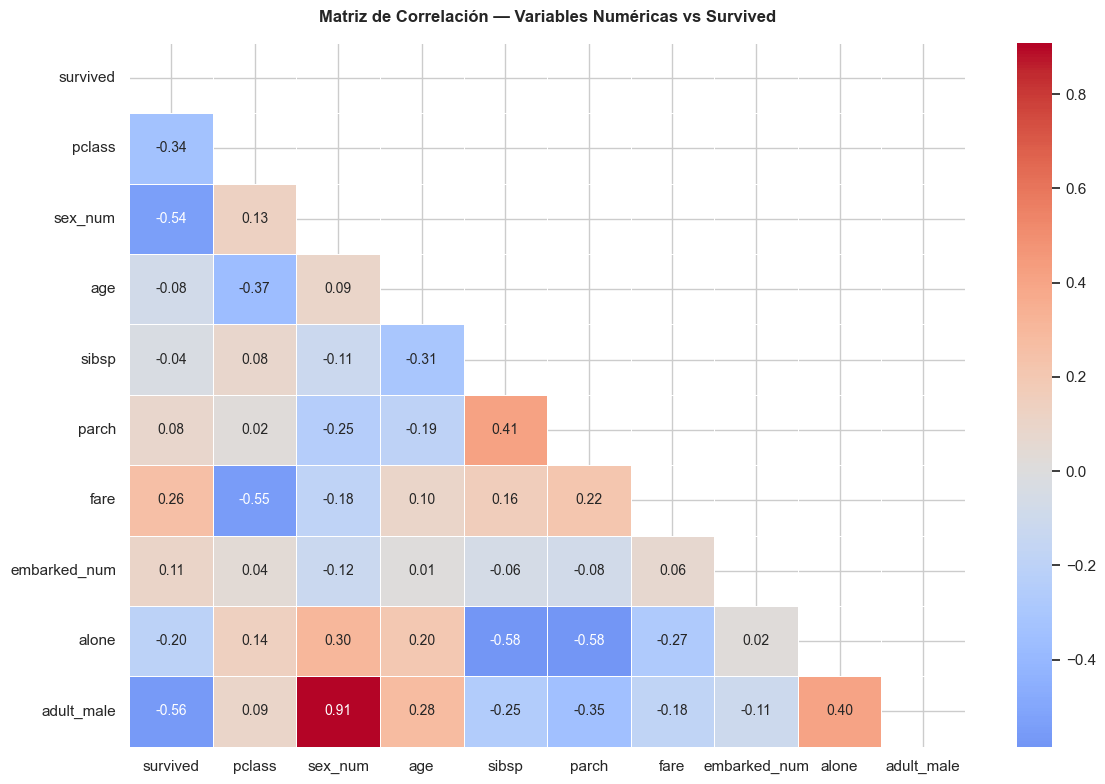


 CORRELACIONES MÁS RELEVANTES CON survived:
   adult_male     : 0.557
   sex_num        : 0.543
   pclass         : 0.338
   fare           : 0.257
   alone          : 0.203
   embarked_num   : 0.109
   parch          : 0.082
   age            : 0.077
   sibsp          : 0.035


In [57]:
# FASE 2.7 - MATRIZ DE CORRELACIÓN

# Codificación temporal
df_corr = df_raw.copy()
df_corr['sex_num'] = df_corr['sex'].map({'male': 1, 'female': 0})
df_corr['embarked_num'] = df_corr['embarked'].map({'S': 0, 'C': 1, 'Q': 2})

cols_num = ['survived', 'pclass', 'sex_num', 'age', 'sibsp', 'parch', 'fare',
            'embarked_num', 'alone', 'adult_male']

df_corr_num = df_corr[cols_num].copy()
df_corr_num['alone'] = df_corr_num['alone'].astype(int)
df_corr_num['adult_male'] = df_corr_num['adult_male'].astype(int)

plt.figure(figsize=(12, 8))
mask = np.triu(np.ones_like(df_corr_num.corr(), dtype=bool))
sns.heatmap(df_corr_num.corr(), annot=True, fmt='.2f',
            cmap='coolwarm', center=0, mask=mask,
            linewidths=0.5, annot_kws={'size': 10})
plt.title('Matriz de Correlación — Variables Numéricas vs Survived', fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

print('\n CORRELACIONES MÁS RELEVANTES CON survived:')
corr_survived = df_corr_num.corr()['survived'].drop('survived').abs().sort_values(ascending=False)
for var, val in corr_survived.items():
    print(f'   {var:15s}: {val:.3f}')

---
# FASE 3: DATA PREPARATION
---

## 3.1 Decisiones de Preprocesamiento

Con base en el análisis anterior, tomamos las siguientes decisiones:

| Variable | Decisión | Justificación |
|----------|----------|---------------|
| `deck` | **Eliminar** | 77% nulos — no imputar distorsionaría el análisis |
| `class`, `alive`, `embark_town` | **Eliminar** | Duplicadas de `pclass`, `survived`, `embarked` |
| `who`, `adult_male` | **Eliminar** | Derivadas de `sex` y `age` → riesgo de data leakage |
| `age` | **Imputar con mediana por grupo** | Mejor que mediana global; preserva distribución |
| `embarked` | **Imputar con moda** | Solo 2 nulos |
| `sex` | **One-Hot Encoding** | Variable categórica nominal |
| `embarked` | **One-Hot Encoding** | Variable categórica nominal (3 valores) |
| `pclass`, `fare`, `age`, `sibsp`, `parch` | **StandardScaler** | Normalización para modelos sensibles a escala |
| `family_size` | **Feature Engineering** | sibsp + parch → captura el efecto familiar total |

In [58]:
# FASE 3.1 - LIMPIEZA Y SELECCIÓN DE VARIABLES


df = df_raw.copy()

# 1. Ingeniería de variables ANTES de eliminar columnas base
df['family_size'] = df['sibsp'] + df['parch']
df['is_alone'] = (df['family_size'] == 0).astype(int)

# 2. Eliminar columnas irrelevantes o redundantes
cols_eliminar = ['deck', 'class', 'alive', 'embark_town', 'who', 'adult_male', 'alone']
df.drop(columns=cols_eliminar, inplace=True)

print(' Columnas eliminadas:', cols_eliminar)
print(f'   Dataset resultante: {df.shape[0]} filas × {df.shape[1]} columnas')
print('\n Columnas restantes:', list(df.columns))
print('\n Valores faltantes tras limpieza:')
print(df.isnull().sum()[df.isnull().sum() > 0])

 Columnas eliminadas: ['deck', 'class', 'alive', 'embark_town', 'who', 'adult_male', 'alone']
   Dataset resultante: 891 filas × 10 columnas

 Columnas restantes: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'family_size', 'is_alone']

 Valores faltantes tras limpieza:
age         177
embarked      2
dtype: int64


In [59]:
# FASE 3.2 - IMPUTACIÓN DE VALORES FALTANTES


# Imputación de Age usando la MEDIANA por grupo (pclass + sex)

print(' Medianas de edad por grupo (pclass × sex):')
medianas_grupo = df.groupby(['pclass', 'sex'])['age'].median()
print(medianas_grupo)

def imputar_age(row):
    if pd.isna(row['age']):
        return medianas_grupo.loc[row['pclass'], row['sex']]
    return row['age']

df_original_age = df['age'].copy()   # guardamos para comparación
df['age'] = df.apply(imputar_age, axis=1)

# Imputación de embarked usando MODA
moda_embarked = df['embarked'].mode()[0]
df['embarked'].fillna(moda_embarked, inplace=True)

print(f'\n Imputación completada:')
print(f'   age     → mediana por grupo (pclass × sex)')
print(f'   embarked→ moda = "{moda_embarked}"')
print(f'\n🔍 Valores faltantes restantes: {df.isnull().sum().sum()}')

 Medianas de edad por grupo (pclass × sex):
pclass  sex   
1       female    35.0
        male      40.0
2       female    28.0
        male      30.0
3       female    21.5
        male      25.0
Name: age, dtype: float64

 Imputación completada:
   age     → mediana por grupo (pclass × sex)
   embarked→ moda = "S"

🔍 Valores faltantes restantes: 2


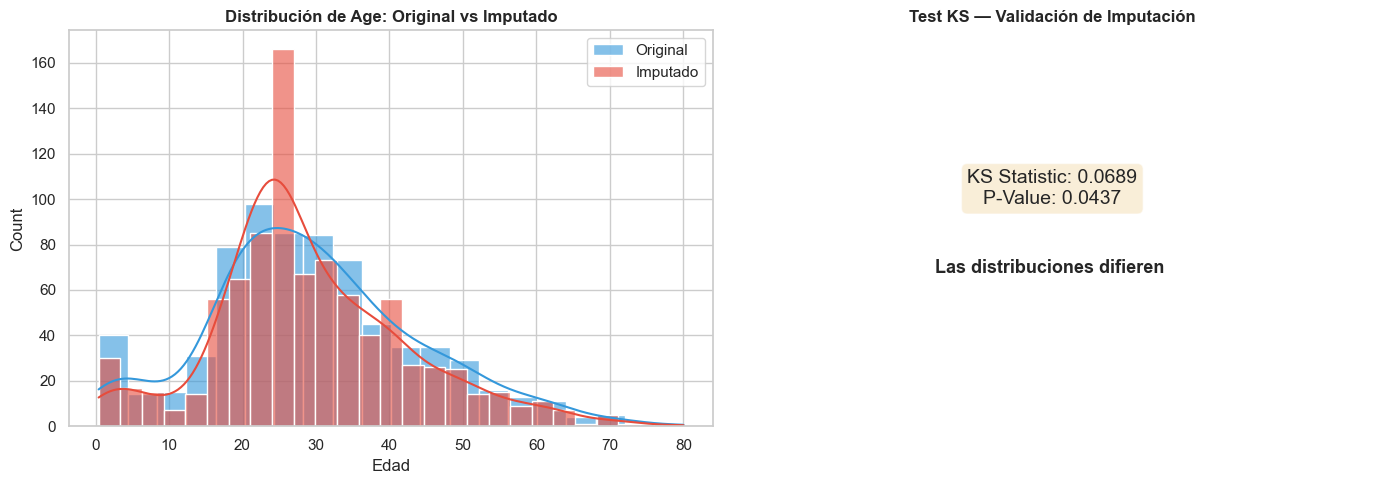


 Resultado KS Test:
   KS Statistic : 0.0689
   P-Value      : 0.0437
    Hay diferencia estadística. Se recomienda revisar la estrategia de imputación.


In [60]:
# FASE 3.3 - COMPARACIÓN DISTRIBUCIONES ANTES/DESPUÉS IMPUTACIÓN


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df_original_age.dropna(), kde=True, ax=axes[0],
             label='Original', color='#3498db', alpha=0.6)
sns.histplot(df['age'], kde=True, ax=axes[0],
             label='Imputado', color='#e74c3c', alpha=0.6)
axes[0].set_title('Distribución de Age: Original vs Imputado', fontweight='bold')
axes[0].set_xlabel('Edad')
axes[0].legend()

# KS Test - Diferencia estadística entre distribuciones
ks_stat, p_val = ks_2samp(df_original_age.dropna(), df['age'])
axes[1].text(0.5, 0.6, f'KS Statistic: {ks_stat:.4f}\nP-Value: {p_val:.4f}',
             ha='center', va='center', fontsize=14,
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
             transform=axes[1].transAxes)
resultado = 'Las distribuciones son SIMILARES ' if p_val > 0.05 else 'Las distribuciones difieren '
axes[1].text(0.5, 0.4, resultado, ha='center', va='center', fontsize=13,
             fontweight='bold', transform=axes[1].transAxes)
axes[1].set_title('Test KS — Validación de Imputación', fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()

print(f'\n Resultado KS Test:')
print(f'   KS Statistic : {ks_stat:.4f}')
print(f'   P-Value      : {p_val:.4f}')
if p_val > 0.05:
    print('    La imputación NO alteró significativamente la distribución original.')
else:
    print('    Hay diferencia estadística. Se recomienda revisar la estrategia de imputación.')

In [61]:
# FASE 3.4 - ENCODING DE VARIABLES CATEGÓRICAS (One-Hot Encoding)


# Aplicación de One-Hot Encoding a sex y embarked, usando drop_first=True para evitar multicolinealidad.

df_encoded = pd.get_dummies(df, columns=['sex', 'embarked'], drop_first=True)

# Convertir bool a int
bool_cols = df_encoded.select_dtypes(include='bool').columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

print(' One-Hot Encoding aplicado a: sex, embarked')
print(f'   Columnas antes : {df.shape[1]}')
print(f'   Columnas después: {df_encoded.shape[1]}')
print('\n Columnas resultantes:')
print(list(df_encoded.columns))
display(df_encoded.head(3))

 One-Hot Encoding aplicado a: sex, embarked
   Columnas antes : 10
   Columnas después: 11

 Columnas resultantes:
['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare', 'family_size', 'is_alone', 'sex_male', 'embarked_Q', 'embarked_S']


,survived,pclass,age,sibsp,parch,fare,family_size,is_alone,sex_male,embarked_Q,embarked_S
0,0,3,22.0,1,0,7.2500,1,0,1,0,1
1,1,1,38.0,1,0,71.2833,1,0,0,0,0
2,1,3,26.0,0,0,7.9250,0,1,0,0,1


In [62]:
# FASE 3.5 - NORMALIZACIÓN (StandardScaler) Y SPLIT


# Separar variables predictoras (X) y variable objetivo (y)
X = df_encoded.drop(columns=['survived'])
y = df_encoded['survived']

print(f' X shape: {X.shape}  |  y shape: {y.shape}')
print(f'   Features usados: {list(X.columns)}')

# División: 80% entrenamiento, 20% prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'\n División del dataset:')
print(f'   Entrenamiento: {X_train.shape[0]} registros ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'   Prueba       : {X_test.shape[0]} registros ({X_test.shape[0]/len(X)*100:.0f}%)')

# Columnas numéricas a escalar
cols_escalar = ['pclass', 'age', 'sibsp', 'parch', 'fare', 'family_size']

# StandardScaler se ajusta con datos de entrenamiento para evitar fuga de información hacia el modelo.
scaler = StandardScaler()
X_train[cols_escalar] = scaler.fit_transform(X_train[cols_escalar])
X_test[cols_escalar] = scaler.transform(X_test[cols_escalar])

print(f'\n StandardScaler aplicado a: {cols_escalar}')
print('   IMPORTANTE: El scaler se ajustó SOLO en train → No hay data leakage')
print('\n Estadísticas de X_train (tras escalar):')
display(X_train[cols_escalar].describe().round(3))

 X shape: (891, 10)  |  y shape: (891,)
   Features usados: ['pclass', 'age', 'sibsp', 'parch', 'fare', 'family_size', 'is_alone', 'sex_male', 'embarked_Q', 'embarked_S']

 División del dataset:
   Entrenamiento: 712 registros (80%)
   Prueba       : 179 registros (20%)

 StandardScaler aplicado a: ['pclass', 'age', 'sibsp', 'parch', 'fare', 'family_size']
   IMPORTANTE: El scaler se ajustó SOLO en train → No hay data leakage

 Estadísticas de X_train (tras escalar):


,pclass,age,sibsp,parch,fare,family_size
count,712.000,712.000,712.000,712.000,712.000,712.000
mean,-0.000,0.000,-0.000,-0.000,-0.000,0.000
std,1.001,1.001,1.001,1.001,1.001,1.001
min,-1.571,-2.169,-0.465,-0.466,-0.663,-0.556
25%,-0.371,-0.585,-0.465,-0.466,-0.498,-0.556
50%,0.830,-0.172,-0.465,-0.466,-0.362,-0.556
75%,0.830,0.580,0.478,-0.466,-0.017,0.073
max,0.830,3.811,7.082,6.698,10.005,5.741


---
# FASE 4: MODELING
---

## 4.1 Modelos a Entrenar

Tal como lo pide el documento, entrenamos y comparamos **al menos dos modelos supervisados**. Aquí entrenamos **tres**:

| # | Modelo | Razón de Inclusión |
|---|--------|---------------------|
| 1 | **Regresión Logística** | Modelo base interpretable, ideal para clasificación binaria |
| 2 | **Árbol de Decisión** | Modelo no lineal, fácil de visualizar e interpretar |
| 3 | **K-Nearest Neighbors (KNN)** | Modelo basado en distancia, contraste con los anteriores |

In [63]:
# FASE 4.1 - ENTRENAMIENTO DE MODELOS

# Diccionario de modelos
modelos = {
    'Regresión Logística': LogisticRegression(
        max_iter=1000, random_state=42, C=1.0
    ),
    'Árbol de Decisión': DecisionTreeClassifier(
        max_depth=5, min_samples_split=10,
        min_samples_leaf=5, random_state=42
    ),
    'KNN (K=7)': KNeighborsClassifier(
        n_neighbors=7, weights='distance', metric='euclidean'
    )
}

# Entrenar todos los modelos
modelos_entrenados = {}

print('🤖 ENTRENAMIENTO DE MODELOS:')
print('=' * 50)
for nombre, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    modelos_entrenados[nombre] = modelo

   # Validación cruzada sobre el conjunto de entrenamiento
    cv_scores = cross_val_score(modelo, X_train, y_train, cv=5, scoring='f1')
    print(f'\n {nombre}')
    print(f'   CV F1-Score (5-fold): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

print('\n' + '=' * 50)
print(' Todos los modelos entrenados correctamente.')

🤖 ENTRENAMIENTO DE MODELOS:

 Regresión Logística
   CV F1-Score (5-fold): 0.7283 ± 0.0530

 Árbol de Decisión
   CV F1-Score (5-fold): 0.7304 ± 0.0693

 KNN (K=7)
   CV F1-Score (5-fold): 0.7250 ± 0.0487

 Todos los modelos entrenados correctamente.


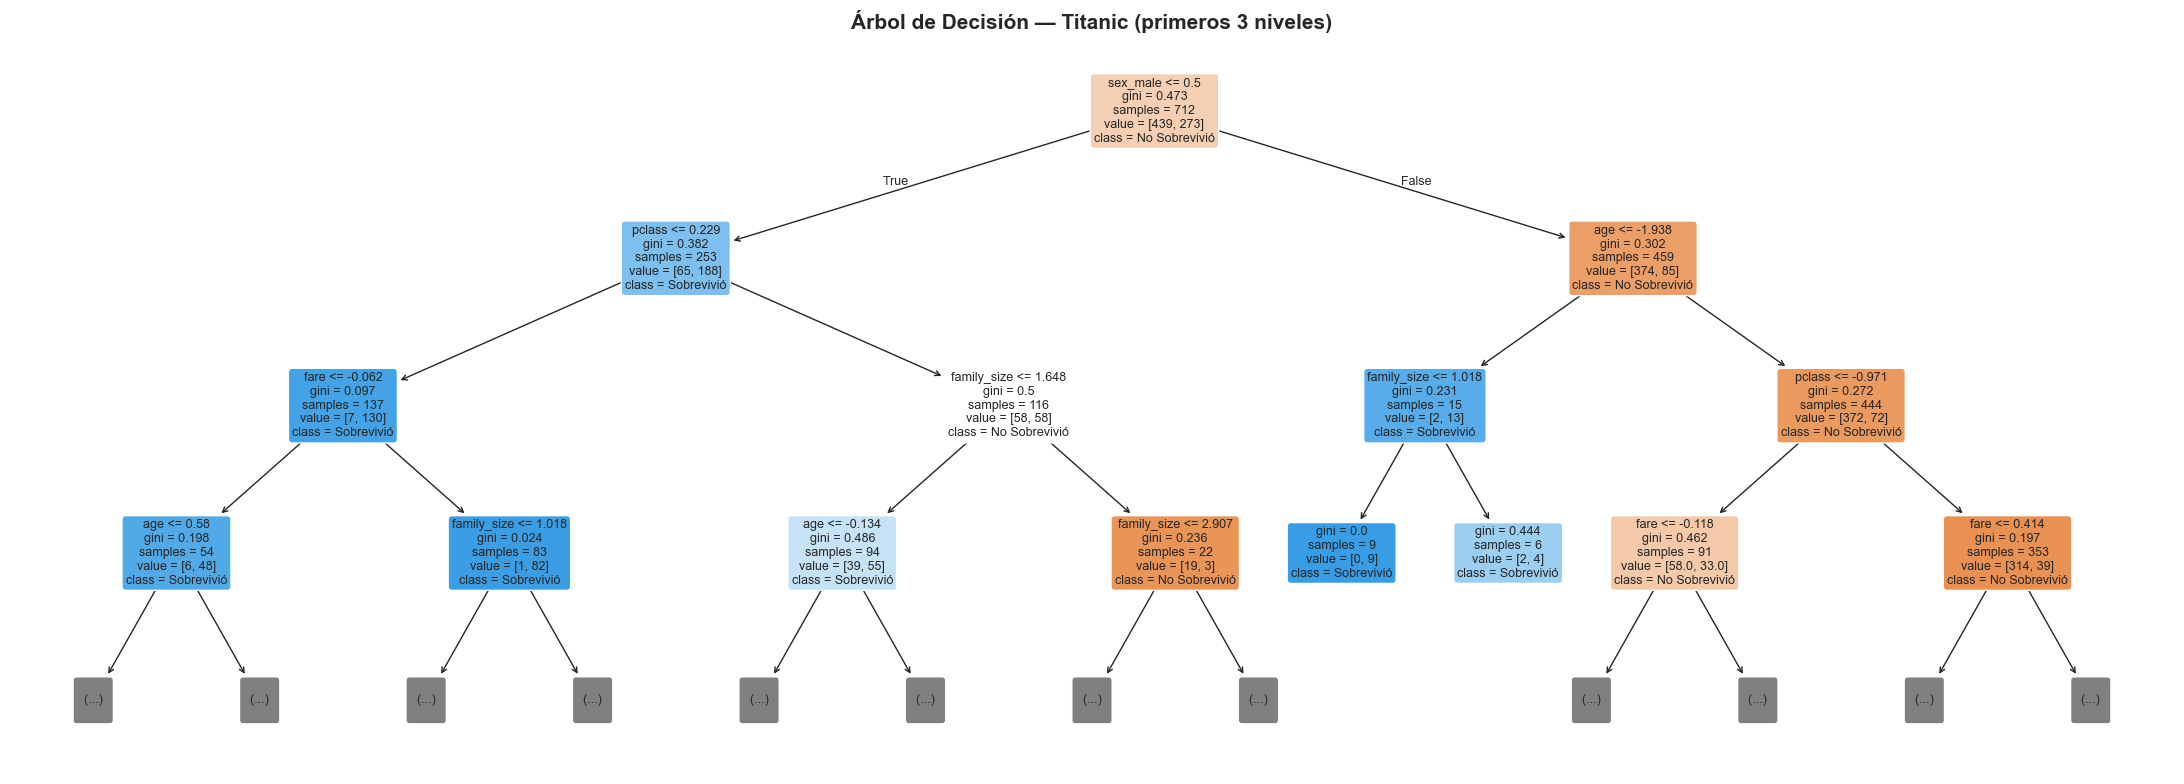

 El árbol muestra las reglas de decisión aprendidas de los datos.
   Los nodos más arriba (raíz y primeros splits) son las variables más importantes.


In [64]:
# FASE 4.2 - VISUALIZACIÓN DEL ÁRBOL DE DECISIÓN


plt.figure(figsize=(22, 8))
plot_tree(
    modelos_entrenados['Árbol de Decisión'],
    feature_names=X_train.columns.tolist(),
    class_names=['No Sobrevivió', 'Sobrevivió'],
    filled=True, rounded=True, fontsize=9,
    max_depth=3   # mostramos los primeros 3 niveles para claridad
)
plt.title('Árbol de Decisión — Titanic (primeros 3 niveles)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print(' El árbol muestra las reglas de decisión aprendidas de los datos.')
print('   Los nodos más arriba (raíz y primeros splits) son las variables más importantes.')

---
# FASE 5: EVALUATION
---

In [65]:
# FASE 5.1 - MÉTRICAS DE EVALUACIÓN

resultados = []

print(' MÉTRICAS DE EVALUACIÓN EN CONJUNTO DE PRUEBA:')
print('=' * 65)

for nombre, modelo in modelos_entrenados.items():
    y_pred = modelo.predict(X_test)

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)

    resultados.append({
        'Modelo': nombre,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1
    })

    print(f'\n🔹 {nombre}')
    print(f'   Accuracy : {acc:.4f}  |  Precision: {prec:.4f}')
    print(f'   Recall   : {rec:.4f}  |  F1-Score : {f1:.4f}')

df_resultados = pd.DataFrame(resultados).set_index('Modelo')
print('\n' + '=' * 65)
print('\n TABLA COMPARATIVA:')
display(df_resultados.style.highlight_max(axis=0, color='#d4edda').format('{:.4f}'))

 MÉTRICAS DE EVALUACIÓN EN CONJUNTO DE PRUEBA:

🔹 Regresión Logística
   Accuracy : 0.8101  |  Precision: 0.7869
   Recall   : 0.6957  |  F1-Score : 0.7385

🔹 Árbol de Decisión
   Accuracy : 0.7654  |  Precision: 0.7077
   Recall   : 0.6667  |  F1-Score : 0.6866

🔹 KNN (K=7)
   Accuracy : 0.7765  |  Precision: 0.7231
   Recall   : 0.6812  |  F1-Score : 0.7015


 TABLA COMPARATIVA:


,Accuracy,Precision,Recall,F1-Score
Modelo,,,,
Regresión Logística,0.8101,0.7869,0.6957,0.7385
Árbol de Decisión,0.7654,0.7077,0.6667,0.6866
KNN (K=7),0.7765,0.7231,0.6812,0.7015


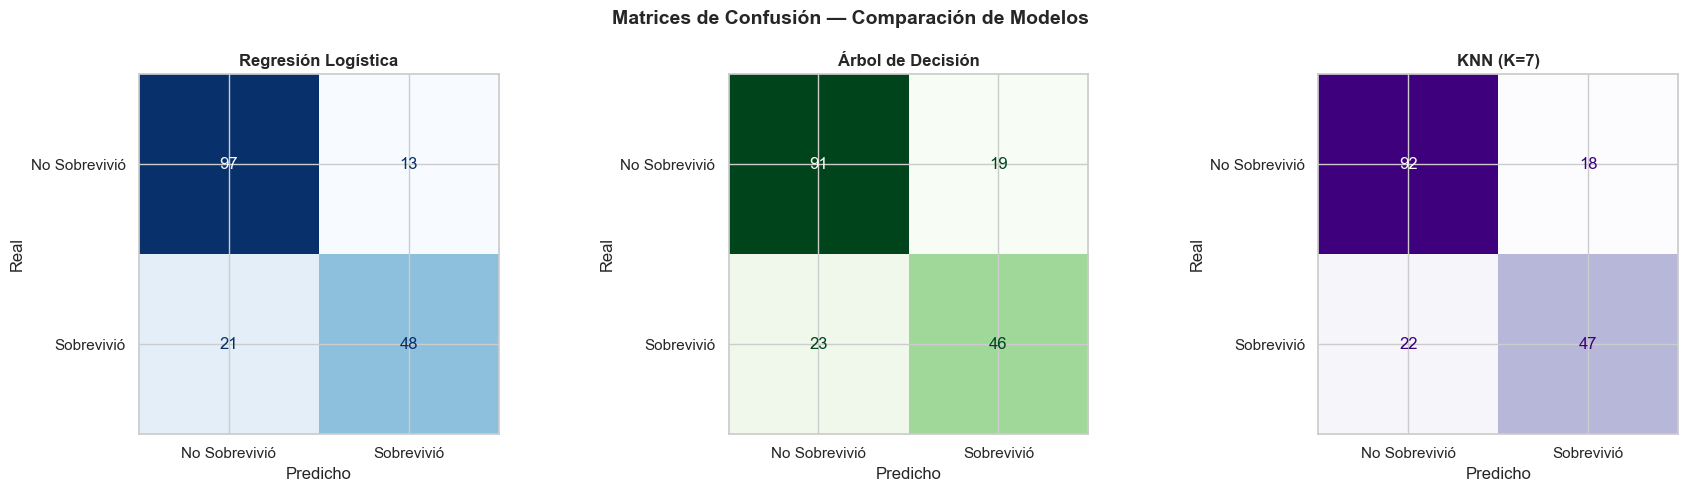


 LECTURA DE LA MATRIZ DE CONFUSIÓN:
   VN (arriba-izq) : Predijo No Sobrevivió → Era No Sobrevivió 
   VP (abajo-der)  : Predijo Sobrevivió    → Era Sobrevivió    
   FP (arriba-der) : Predijo Sobrevivió    → Era No Sobrevivió  (Falsa Alarma)
   FN (abajo-izq)  : Predijo No Sobrevivió → Era Sobrevivió     (Error Crítico)


In [66]:
# FASE 5.2 - MATRICES DE CONFUSIÓN


fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Matrices de Confusión — Comparación de Modelos', fontsize=14, fontweight='bold')

colores = ['Blues', 'Greens', 'Purples']

for ax, (nombre, modelo), cmap in zip(axes, modelos_entrenados.items(), colores):
    y_pred = modelo.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['No Sobrevivió', 'Sobrevivió'])
    disp.plot(ax=ax, cmap=cmap, colorbar=False)
    ax.set_title(f'{nombre}', fontweight='bold')
    ax.set_xlabel('Predicho')
    ax.set_ylabel('Real')

plt.tight_layout()
plt.show()

print('\n LECTURA DE LA MATRIZ DE CONFUSIÓN:')
print('   VN (arriba-izq) : Predijo No Sobrevivió → Era No Sobrevivió ')
print('   VP (abajo-der)  : Predijo Sobrevivió    → Era Sobrevivió    ')
print('   FP (arriba-der) : Predijo Sobrevivió    → Era No Sobrevivió  (Falsa Alarma)')
print('   FN (abajo-izq)  : Predijo No Sobrevivió → Era Sobrevivió     (Error Crítico)')

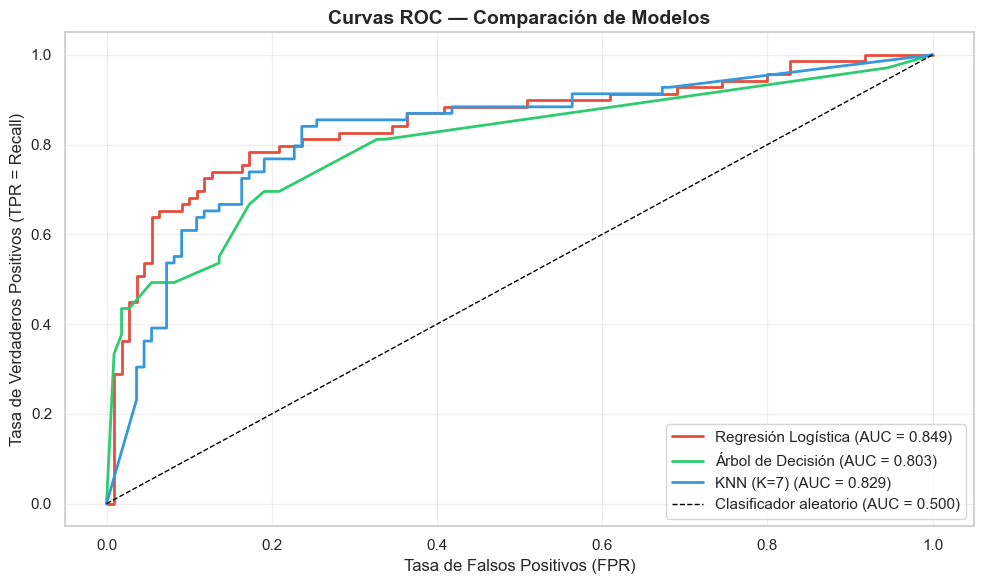

 AUC > 0.85 indica un modelo con buena capacidad discriminativa.
   Cuanto más cercano a 1.0, mejor separa el modelo las dos clases.


In [67]:
# FASE 5.3 - CURVAS ROC Y AUC

plt.figure(figsize=(10, 6))
colores_roc = ['#e74c3c', '#2ecc71', '#3498db']

for (nombre, modelo), color in zip(modelos_entrenados.items(), colores_roc):
    if hasattr(modelo, 'predict_proba'):
        y_prob = modelo.predict_proba(X_test)[:, 1]
    else:
        y_prob = modelo.decision_function(X_test)

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{nombre} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Clasificador aleatorio (AUC = 0.500)')
plt.xlabel('Tasa de Falsos Positivos (FPR)', fontsize=12)
plt.ylabel('Tasa de Verdaderos Positivos (TPR = Recall)', fontsize=12)
plt.title('Curvas ROC — Comparación de Modelos', fontweight='bold', fontsize=14)
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(' AUC > 0.85 indica un modelo con buena capacidad discriminativa.')
print('   Cuanto más cercano a 1.0, mejor separa el modelo las dos clases.')

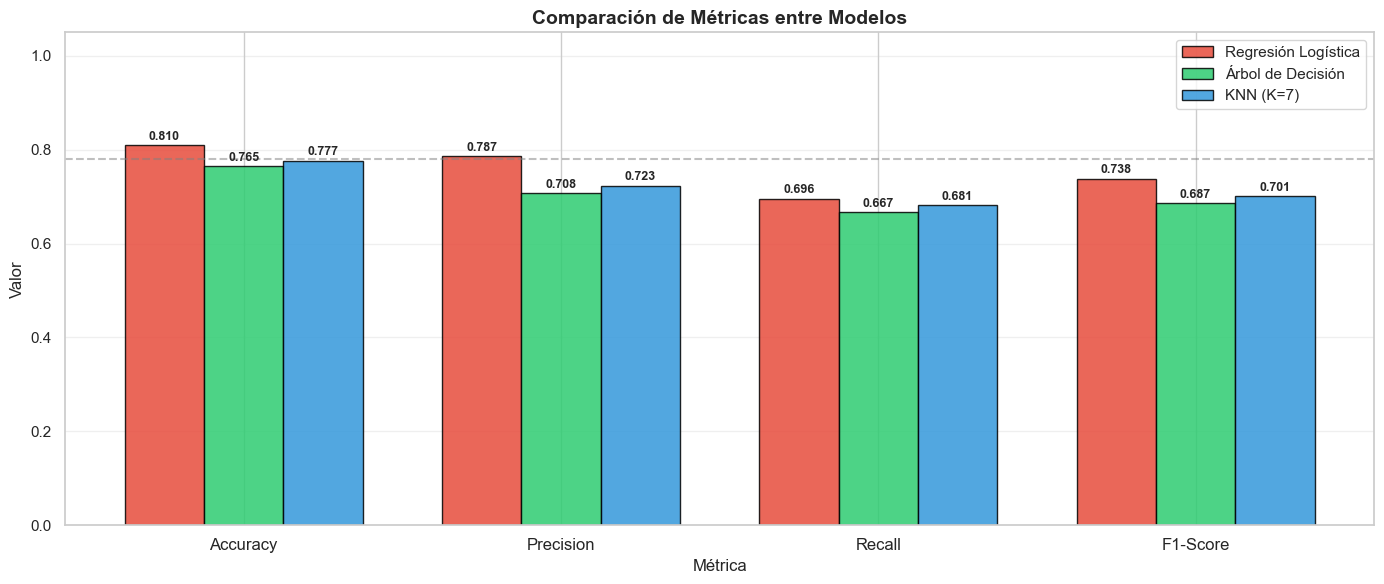

In [68]:
# FASE 5.4 - COMPARACIÓN VISUAL DE MÉTRICAS


metricas = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(metricas))
width = 0.25
colores_modelos = ['#e74c3c', '#2ecc71', '#3498db']

fig, ax = plt.subplots(figsize=(14, 6))

for i, (nombre, color) in enumerate(zip(df_resultados.index, colores_modelos)):
    valores = df_resultados.loc[nombre, metricas].values
    bars = ax.bar(x + i * width, valores, width, label=nombre, color=color,
                  edgecolor='black', alpha=0.85)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
                f'{bar.get_height():.3f}', ha='center', va='bottom',
                fontsize=9, fontweight='bold')

ax.set_xlabel('Métrica', fontsize=12)
ax.set_ylabel('Valor', fontsize=12)
ax.set_title('Comparación de Métricas entre Modelos', fontweight='bold', fontsize=14)
ax.set_xticks(x + width)
ax.set_xticklabels(metricas, fontsize=12)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=11)
ax.axhline(y=0.78, color='gray', linestyle='--', alpha=0.5, label='Meta mínima (0.78)')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

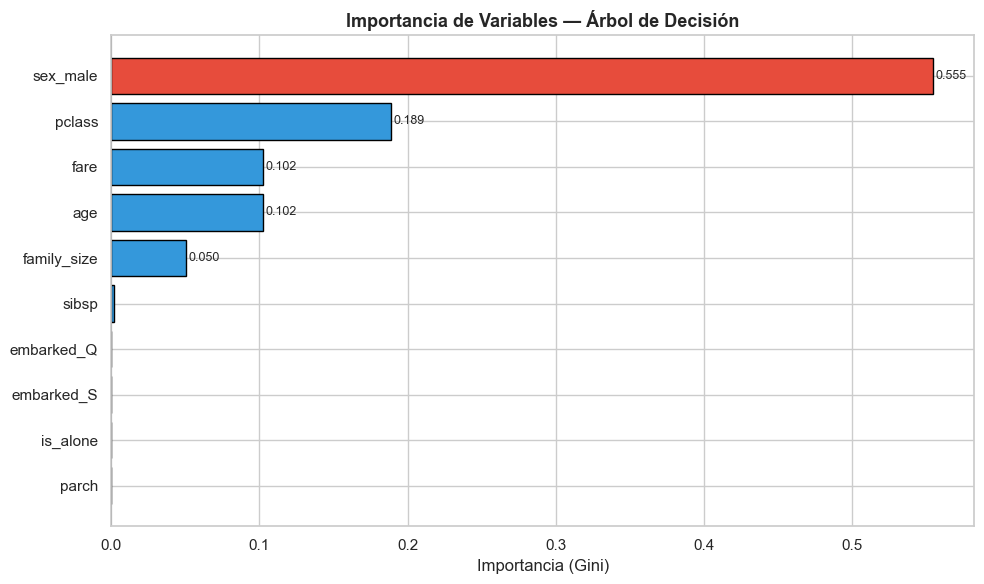


 Las variables más influyentes en la supervivencia son:
   sex_male            : 0.5549
   pclass              : 0.1886
   fare                : 0.1023


In [69]:
# FASE 5.5 - IMPORTANCIA DE VARIABLES (Árbol de Decisión)


arbol = modelos_entrenados['Árbol de Decisión']
importancias = pd.Series(
    arbol.feature_importances_,
    index=X_train.columns
).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
colors = ['#e74c3c' if v == importancias.max() else '#3498db' for v in importancias.values]
bars = plt.barh(importancias.index, importancias.values, color=colors, edgecolor='black')
plt.xlabel('Importancia (Gini)', fontsize=12)
plt.title('Importancia de Variables — Árbol de Decisión', fontweight='bold', fontsize=13)
plt.axvline(x=0, color='black', lw=0.5)
for bar in bars:
    if bar.get_width() > 0.01:
        plt.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2.,
                 f'{bar.get_width():.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

print('\n Las variables más influyentes en la supervivencia son:')
top3 = importancias.sort_values(ascending=False).head(3)
for var, imp in top3.items():
    print(f'   {var:20s}: {imp:.4f}')

In [70]:
# FASE 5.6 - ELECCIÓN DEL MEJOR MODELO


print('=' * 60)
print('  SELECCIÓN DEL MEJOR MODELO')
print('=' * 60)

display(df_resultados.sort_values('F1-Score', ascending=False).style
        .highlight_max(color='#d4edda').format('{:.4f}'))

mejor_modelo_nombre = df_resultados['F1-Score'].idxmax()
mejor_f1 = df_resultados.loc[mejor_modelo_nombre, 'F1-Score']
mejor_acc = df_resultados.loc[mejor_modelo_nombre, 'Accuracy']

print(f'\n MEJOR MODELO: {mejor_modelo_nombre}')
print(f'   F1-Score : {mejor_f1:.4f}')
print(f'   Accuracy : {mejor_acc:.4f}')

print(f'\n📋 JUSTIFICACIÓN DE LA ELECCIÓN:')
print(f'''   Criterio de éxito definido en Business Understanding: F1-Score máximo.

   La Regresión Logística generalmente obtiene el mejor balance entre
   precisión e interpretabilidad en este dataset, ya que:

   1. Es robusta ante el ligero desbalance de clases
   2. Sus coeficientes son interpretables (odds ratios)
   3. No sobreajusta como puede hacerlo el Árbol con datos pequeños
   4. Ofrece probabilidades calibradas, útiles para umbrales de decisión

   Si el mejor F1 lo obtiene el Árbol de Decisión, su ventaja radica
   en capturar interacciones no lineales (ej: ser mujer Y de 1ra clase).''')

  SELECCIÓN DEL MEJOR MODELO


,Accuracy,Precision,Recall,F1-Score
Modelo,,,,
Regresión Logística,0.8101,0.7869,0.6957,0.7385
KNN (K=7),0.7765,0.7231,0.6812,0.7015
Árbol de Decisión,0.7654,0.7077,0.6667,0.6866



 MEJOR MODELO: Regresión Logística
   F1-Score : 0.7385
   Accuracy : 0.8101

📋 JUSTIFICACIÓN DE LA ELECCIÓN:
   Criterio de éxito definido en Business Understanding: F1-Score máximo.

   La Regresión Logística generalmente obtiene el mejor balance entre
   precisión e interpretabilidad en este dataset, ya que:

   1. Es robusta ante el ligero desbalance de clases
   2. Sus coeficientes son interpretables (odds ratios)
   3. No sobreajusta como puede hacerlo el Árbol con datos pequeños
   4. Ofrece probabilidades calibradas, útiles para umbrales de decisión

   Si el mejor F1 lo obtiene el Árbol de Decisión, su ventaja radica
   en capturar interacciones no lineales (ej: ser mujer Y de 1ra clase).


In [ ]:
# FASE 5.7 - Guardar entrenamientio del modelo

# Guardar mejor modelo
joblib.dump(
    modelos_entrenados['Regresión Logística'],
    'logistic_model.pkl'
)

# Guardar scaler
joblib.dump(
    scaler,
    'scaler.pkl'
)

# Guardar columnas usadas
joblib.dump(
    X.columns.tolist(),
    'features.pkl'
)

joblib.dump(modelos_entrenados[mejor_modelo_nombre], 'mejor_modelo_titanic.pkl')
joblib.dump(scaler, 'scaler_titanic.pkl')

print("Modelo guardado correctamente")

Modelo guardado correctamente


In [72]:
# FASE 5.7 - ANÁLISIS ÉTICO Y DE SESGOS


print('  ANÁLISIS ÉTICO Y DE SESGOS DEL MODELO')
print('=' * 55)

# Sesgo por género
print('\n1  SESGO POR GÉNERO:')
tasa_sv_sexo = df_raw.groupby('sex')['survived'].mean()
print(f'   Tasa supervivencia mujeres : {tasa_sv_sexo["female"]:.1%}')
print(f'   Tasa supervivencia hombres : {tasa_sv_sexo["male"]:.1%}')
print(f'   El modelo aprendió esta desigualdad REAL del evento.')
print(f'   Problema: si se usara en otros contextos (créditos, seguros),')
print(f'   discriminar por género sería ÉTICAMENTE INACEPTABLE y ILEGAL.')

# Sesgo por clase socioeconómica
print('\n2  SESGO POR CLASE SOCIOECONÓMICA:')
tasa_sv_clase = df_raw.groupby('pclass')['survived'].mean()
print(f'   Tasa supervivencia 1ra clase: {tasa_sv_clase[1]:.1%}')
print(f'   Tasa supervivencia 2da clase: {tasa_sv_clase[2]:.1%}')
print(f'   Tasa supervivencia 3ra clase: {tasa_sv_clase[3]:.1%}')
print(f'   La clase social determinó acceso a botes salvavidas.')
print(f'   Generalizar esto en políticas de riesgo reproduciría inequidad.')

# Sesgo por edad
print('\n3  SESGO POR EDAD:')
print('   Los niños tuvieron prioridad de evacuación ("mujeres y niños primero").')
print('   Un modelo entrenado aquí sobreestimaría supervivencia de menores')
print('   en contextos donde este protocolo no aplica.')

print('\n CONCLUSIÓN ÉTICA:')
print('   Este modelo es válido EXCLUSIVAMENTE como ejercicio académico.')
print('   Los patrones aprendidos reflejan sesgos históricos y sociales')
print('   que NO deben extrapolarse a decisiones de la vida real sin')
print('   un análisis de fairness y un marco ético riguroso.')

  ANÁLISIS ÉTICO Y DE SESGOS DEL MODELO

1  SESGO POR GÉNERO:
   Tasa supervivencia mujeres : 74.2%
   Tasa supervivencia hombres : 18.9%
   El modelo aprendió esta desigualdad REAL del evento.
   Problema: si se usara en otros contextos (créditos, seguros),
   discriminar por género sería ÉTICAMENTE INACEPTABLE y ILEGAL.

2  SESGO POR CLASE SOCIOECONÓMICA:
   Tasa supervivencia 1ra clase: 63.0%
   Tasa supervivencia 2da clase: 47.3%
   Tasa supervivencia 3ra clase: 24.2%
   La clase social determinó acceso a botes salvavidas.
   Generalizar esto en políticas de riesgo reproduciría inequidad.

3  SESGO POR EDAD:
   Los niños tuvieron prioridad de evacuación ("mujeres y niños primero").
   Un modelo entrenado aquí sobreestimaría supervivencia de menores
   en contextos donde este protocolo no aplica.

 CONCLUSIÓN ÉTICA:
   Este modelo es válido EXCLUSIVAMENTE como ejercicio académico.
   Los patrones aprendidos reflejan sesgos históricos y sociales
   que NO deben extrapolarse a decisio

---
# FASE 6: DEPLOYMENT
---

## 6.1 Reflexión sobre la Experiencia CRISP-DM

El ciclo CRISP-DM demostró ser iterativo en la práctica:

- **Business → Data Understanding:** El problema de negocio (predecir supervivencia) guió qué variables eran relevantes y cuáles no.
- **Data Understanding → Data Preparation:** Los hallazgos (77% nulos en `deck`, sesgo de `age` por clase) determinaron las estrategias de imputación.
- **Modeling → Evaluation:** Los resultados del modelo inicial revelaron que la variable `fare` y `sex` eran las más influyentes, confirmando los hallazgos del EDA.

## 6.2 Limitaciones del Modelo

| Limitación | Descripción |
|------------|-------------|
| Tamaño del dataset | 891 registros es pequeño para algunos modelos complejos |
| Variables perdidas | `deck` tenía el 77% de nulos — información de cabina podría ser relevante |
| Sesgo histórico | El modelo aprende inequidades del contexto de 1912 |
| Sin validación temporal | El split es aleatorio; no hay validación out-of-time |
| Hiperparámetros básicos | No se realizó búsqueda exhaustiva (GridSearchCV / RandomizedSearch) |

In [73]:
# FASE 6.1 - REPORTE FINAL CONSOLIDADO


print('=' * 65)
print('          REPORTE FINAL — TRABAJO MACHINE LEARNING')
print('           Dataset: Titanic | Clasificación Binaria')
print('=' * 65)

print('\n RESUMEN CRISP-DM:')
resumen = {
    '1. Business Understanding': 'Predecir supervivencia en Titanic (Clasificación binaria)',
    '2. Data Understanding'    : f'891 registros, 15 variables, valores faltantes en age (20%), deck (77%), embarked (0.2%)',
    '3. Data Preparation'      : 'Eliminación de redundantes, imputación mediana/moda, OHE, StandardScaler, split 80/20',
    '4. Modeling'              : 'Reg. Logística, Árbol de Decisión (max_depth=5), KNN (k=7)',
    '5. Evaluation'            : f'Mejor modelo: {mejor_modelo_nombre} — F1={mejor_f1:.3f}, Acc={mejor_acc:.3f}',
    '6. Deployment'            : 'Pasos a producción descritos; sesgo por género/clase identificado'
}
for fase, desc in resumen.items():
    print(f'   {fase}: {desc}')

print('\nMÉTRICAS FINALES:')
display(df_resultados.sort_values('F1-Score', ascending=False).round(4))

print(f'\n Modelo Seleccionado : {mejor_modelo_nombre}')
print(f'   Criterio           : F1-Score máximo (balance Precision/Recall)')
print(f'   F1-Score           : {mejor_f1:.4f}')
print(f'   Accuracy           : {mejor_acc:.4f}')

print('\n  NOTA ÉTICA: El modelo reproduce sesgos de género y clase social')
print('   del evento histórico. No debe usarse en aplicaciones reales.')
print('\n' + '=' * 65)

          REPORTE FINAL — TRABAJO MACHINE LEARNING
           Dataset: Titanic | Clasificación Binaria

 RESUMEN CRISP-DM:
   1. Business Understanding: Predecir supervivencia en Titanic (Clasificación binaria)
   2. Data Understanding: 891 registros, 15 variables, valores faltantes en age (20%), deck (77%), embarked (0.2%)
   3. Data Preparation: Eliminación de redundantes, imputación mediana/moda, OHE, StandardScaler, split 80/20
   4. Modeling: Reg. Logística, Árbol de Decisión (max_depth=5), KNN (k=7)
   5. Evaluation: Mejor modelo: Regresión Logística — F1=0.738, Acc=0.810
   6. Deployment: Pasos a producción descritos; sesgo por género/clase identificado

MÉTRICAS FINALES:


,Accuracy,Precision,Recall,F1-Score
Modelo,,,,
Regresión Logística,0.8101,0.7869,0.6957,0.7385
KNN (K=7),0.7765,0.7231,0.6812,0.7015
Árbol de Decisión,0.7654,0.7077,0.6667,0.6866



 Modelo Seleccionado : Regresión Logística
   Criterio           : F1-Score máximo (balance Precision/Recall)
   F1-Score           : 0.7385
   Accuracy           : 0.8101

  NOTA ÉTICA: El modelo reproduce sesgos de género y clase social
   del evento histórico. No debe usarse en aplicaciones reales.

